In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
data = pd.read_csv('car_prices.csv')
df = data.copy()
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

Checking duplicates and null values

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


Dropping ID columns

In [ ]:
df = df.drop(columns=['car_ID'])
X = df.drop('price', axis=1)
true_y = df['price']
y = np.log1p(df['price'])

Y is skewed

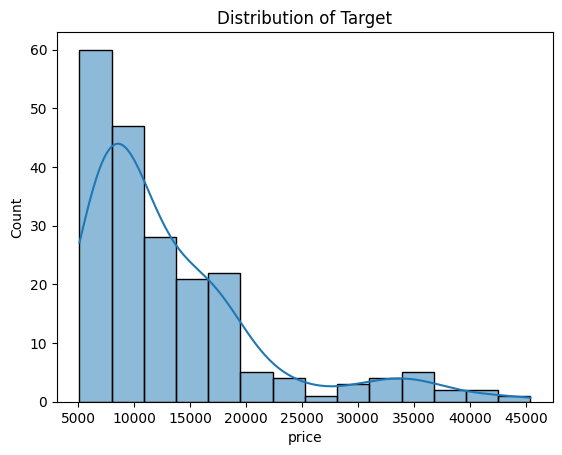

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(true_y, kde=True)
plt.title("Distribution of Target")
plt.show()

Categorical and Numerical columns treatment

In [ ]:
num_col = X.select_dtypes(include=np.number).columns.tolist()
cat_col = X.select_dtypes(include='object').columns.tolist()

In [ ]:
for col in cat_col:
    X[col] = X[col].fillna(X[col].mode()[0])

In [ ]:
for col in cat_col:
    print(col)
    print(X[col].unique())
    print('-' * 40)

CarName
['alfa-romero giulia' 'alfa-romero stelvio' 'alfa-romero Quadrifoglio'
 'audi 100 ls' 'audi 100ls' 'audi fox' 'audi 5000' 'audi 4000'
 'audi 5000s (diesel)' 'bmw 320i' 'bmw x1' 'bmw x3' 'bmw z4' 'bmw x4'
 'bmw x5' 'chevrolet impala' 'chevrolet monte carlo' 'chevrolet vega 2300'
 'dodge rampage' 'dodge challenger se' 'dodge d200' 'dodge monaco (sw)'
 'dodge colt hardtop' 'dodge colt (sw)' 'dodge coronet custom'
 'dodge dart custom' 'dodge coronet custom (sw)' 'honda civic'
 'honda civic cvcc' 'honda accord cvcc' 'honda accord lx'
 'honda civic 1500 gl' 'honda accord' 'honda civic 1300' 'honda prelude'
 'honda civic (auto)' 'isuzu MU-X' 'isuzu D-Max ' 'isuzu D-Max V-Cross'
 'jaguar xj' 'jaguar xf' 'jaguar xk' 'maxda rx3' 'maxda glc deluxe'
 'mazda rx2 coupe' 'mazda rx-4' 'mazda glc deluxe' 'mazda 626' 'mazda glc'
 'mazda rx-7 gs' 'mazda glc 4' 'mazda glc custom l' 'mazda glc custom'
 'buick electra 225 custom' 'buick century luxus (sw)' 'buick century'
 'buick skyhawk' 'buick ope

From the above values we have observed anomalies in the car names given.
we are going to seperate the brand name from the car name, drop car name column and then clean the anomalies.

In [ ]:
X['brand'] = X['CarName'].str.split(' ', n = 1, expand = True)[0]
X.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,brand
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,alfa-romero
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,alfa-romero
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,alfa-romero
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,audi
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,audi


In [ ]:
X = X.drop(columns=['CarName'])

In [ ]:
# now cleaning the misspelled names in the brand.

X['brand'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [ ]:
# mis spelled names:
# alfa_romero: alfa_romeo
# maxda: mazda
# procshce: porsche
#toyouta: toyota
#vokswagen:volkswagen:vw

mis_spl = {
    'alfa-romero': 'alfa-romeo',
    'maxda': 'mazda',
    'procshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen':'volkswagen',
    'vw':'volkswagen',
}

X['brand'] = X['brand'].replace(mis_spl)
X['brand'].unique()

array(['alfa-romeo', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche', 'porcshce',
       'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo'],
      dtype=object)

Proper encoding/mapping of values

In [ ]:
X['fueltype'] = X['fueltype'].map({'gas': 0, 'diesel': 1})
X['aspiration'] = X['aspiration'].map({'std': 0, 'turbo': 1})
X['enginelocation'] = X['enginelocation'].map({'front': 0, 'rear': 1})

X['doornumber'] = X['doornumber'].map({'two': 2, 'four': 4})
X['cylindernumber'] = X['cylindernumber'].map({
    'two': 2, 'three': 3, 'four': 4,
    'five': 5, 'six': 6, 'eight': 8, 'twelve': 12})

In [ ]:
cat_col = X.select_dtypes(include='object').columns.tolist()
num_col = X.select_dtypes(include=np.number).columns.tolist()

In [ ]:
continuous = [
    'wheelbase','carlength','carwidth','carheight',
    'curbweight','enginesize','boreratio','stroke',
    'compressionratio','horsepower','peakrpm',
    'citympg','highwaympg'
]

binary = ['fueltype','aspiration','enginelocation']

ordinal = ['doornumber','cylindernumber','symboling']

nominal_cols = [
    'carbody',
    'drivewheel',
    'enginetype',
    'fuelsystem', 'brand'
]


Analysis

In [ ]:
X[continuous].describe()

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220
std,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443
min,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000
25%,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000
50%,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000
75%,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000


Outlier treatment decision:
IQR-based analysis shows most continuous features have <5% outliers.
'stroke' (9.7%) and 'compressionratio' (~13.6%) have higher outlier rates.

In [ ]:
outlier_summary = {}

for col in continuous:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((X[col] < lower) | (X[col] > upper)).sum()
    outlier_summary[col] = round((outliers / len(X)) * 100, 2)

outlier_summary

{'wheelbase': np.float64(1.46),
 'carlength': np.float64(0.49),
 'carwidth': np.float64(3.9),
 'carheight': np.float64(0.0),
 'curbweight': np.float64(0.0),
 'enginesize': np.float64(4.88),
 'boreratio': np.float64(0.0),
 'stroke': np.float64(9.76),
 'compressionratio': np.float64(13.66),
 'horsepower': np.float64(2.93),
 'peakrpm': np.float64(0.98),
 'citympg': np.float64(0.98),
 'highwaympg': np.float64(1.46)}

CompressionRatio is heavily skewed

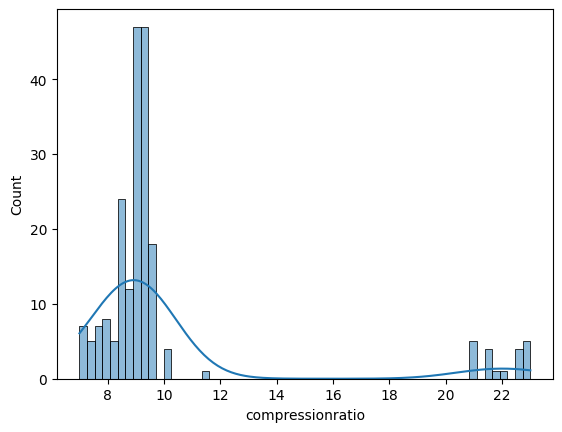

In [ ]:
sns.histplot(X['compressionratio'], kde=True)
plt.show()

In [ ]:
X.loc[X['compressionratio'] <= 0, 'compressionratio'] = np.nan
X.loc[X['compressionratio'] > 14, 'compressionratio'] = np.nan

In [ ]:
X['compressionratio'] = X['compressionratio'].fillna(
    X['compressionratio'].median()
)

In [ ]:
Q1 = X['compressionratio'].quantile(0.25)
Q3 = X['compressionratio'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X['compressionratio'] = np.clip(X['compressionratio'], lower, upper)

In [ ]:
((X['compressionratio'] < lower) |
 (X['compressionratio'] > upper)).mean() * 100

np.float64(0.0)

The following features show strong positive correlation with each other:

* wheelbase

* carlength

* carwidth

* curbweight

* enginesize

* horsepower

This indicates that larger cars tend to be heavier and have bigger engines with higher horsepower.

citympg and highwaympg are highly correlated with each other.
This suggests potential redundancy in linear modelinng

<Axes: >

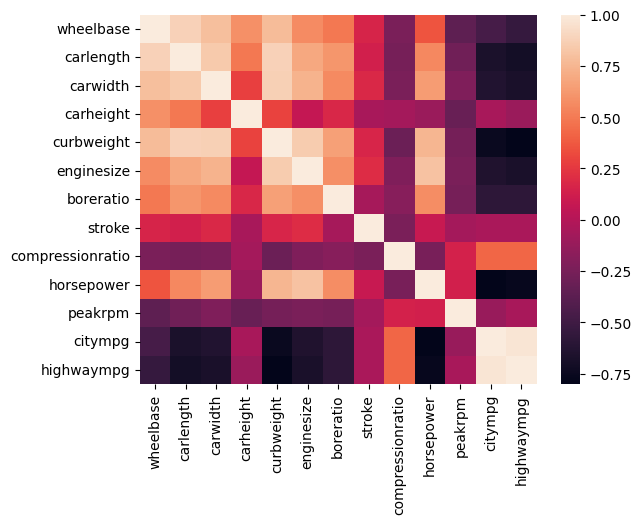

In [ ]:
sns.heatmap(X[continuous].corr())

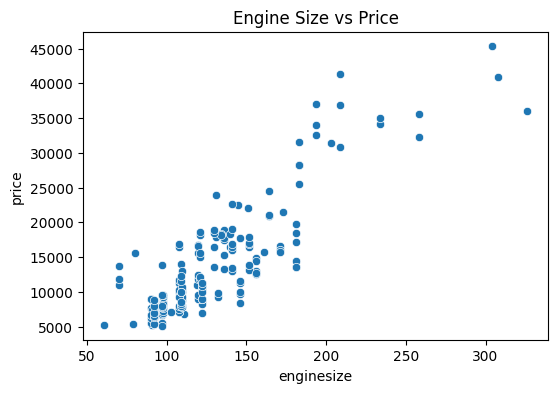

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='enginesize', y='price', data=df)
plt.title("Engine Size vs Price")
plt.show()

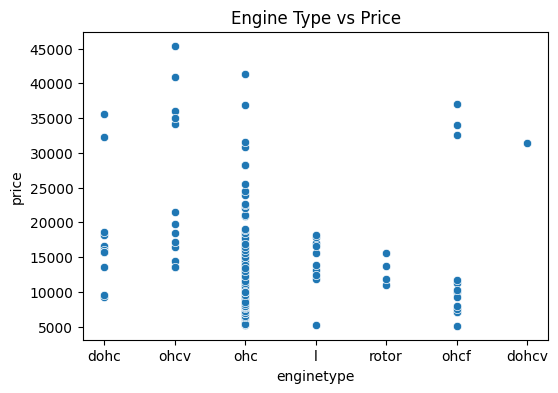

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='enginetype', y='price', data=df)
plt.title("Engine Type vs Price")
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='', y='price', data=df)
plt.title("Curb Weight vs Price")
plt.show()

<Axes: xlabel='carbody', ylabel='price'>

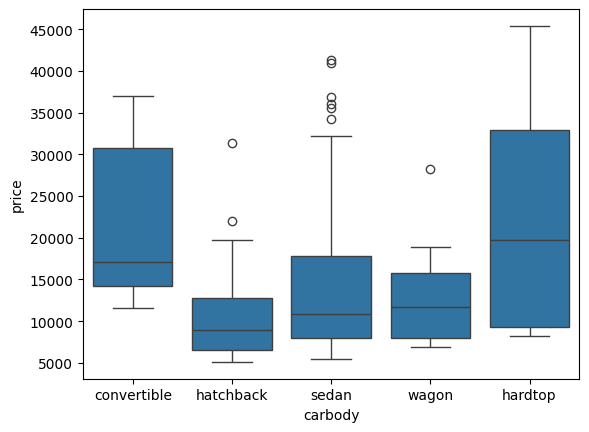

In [ ]:
sns.boxplot(x='carbody', y='price', data=df)

ONE HOT ENCODING

In [ ]:
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model 1 - Ridge

In [ ]:
from sklearn.linear_model import RidgeCV
import numpy as np

alphas = np.logspace(-3, 3, 50)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

print("Best alpha:", ridge.alpha_)

Best alpha: 19.306977288832496


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred_log = ridge.predict(X_test)

print("R2 (log):", r2_score(y_test, y_pred_log))

# Convert back properly
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

print("RMSE (original):",
      np.sqrt(mean_squared_error(y_test_original, y_pred)))

rmsle = np.sqrt(mean_squared_log_error(y_test_original, y_pred))
print("RMSLE:", rmsle)

R2 (log): 0.9285812709737932
RMSE (original): 2407.1387589089336
RMSLE: 0.13919342578001728


In [ ]:
comparison = pd.DataFrame({
    "Actual Price": np.expm1(y_test),
    "Predicted Price": y_pred
})
print(comparison)

     Actual Price  Predicted Price
15      30760.000     29088.446231
9       17859.167     19875.777018
100      9549.000      8959.172925
132     11850.000     13982.192720
68      28248.000     28963.099770
95       7799.000      6795.677115
159      7788.000      7944.931973
162      9258.000      7429.558211
147     10198.000      9197.582032
182      7775.000      8661.121050
191     13295.000     13159.059219
164      8238.000      7692.595562
65      18280.000     15324.506880
175      9988.000      9979.539409
73      40960.000     46402.107390
152      6488.000      6398.045514
18       5151.000      3904.775437
82      12629.000     12399.171545
86       8189.000      8728.289656
143      9960.000      9261.304641
60       8495.000     10058.907220
101     13499.000     15911.183689
98       8249.000      6511.223702
30       6479.000      5360.019487
25       6692.000      6684.413719
16      41315.000     30595.736751
168      9639.000     11288.550549
195     13415.000   

Model 2 - Linear Regression

In [ ]:
X_lr = X.drop(columns=['highwaympg'])
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y, test_size=0.2, random_state=42
)

scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train_lr)
X_test_lr = scaler_lr.transform(X_test_lr)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_log_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train_lr, y_train_lr)

y_pred_lr = lr.predict(X_test_lr)

print("Linear Regression (without highwaympg)")
print("R2 (log):", r2_score(y_test_lr, y_pred_lr))
print("RMSLE:", np.sqrt(mean_squared_log_error(
    np.expm1(y_test_lr), np.expm1(y_pred_lr)
)))

Linear Regression (without highwaympg)
R2 (log): 0.9392034629934038
RMSLE: 0.12842574279064403


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_log_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("R2 (log):", r2_score(y_test, y_pred_lr))
print("RMSLE:", np.sqrt(mean_squared_log_error(
    np.expm1(y_test), np.expm1(y_pred_lr)
)))
print("-" * 40)

Linear Regression
R2 (log): 0.937297652460978
RMSLE: 0.13042311407347162
----------------------------------------


(Best) Model 3 - Tree model (RandomForest)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("R2 (log):", r2_score(y_test, y_pred_rf))
print("RMSLE:", np.sqrt(mean_squared_log_error(
    np.expm1(y_test), np.expm1(y_pred_rf)
)))
print("-" * 40)

Random Forest
R2 (log): 0.9531189339662148
RMSLE: 0.11277462830531124
----------------------------------------


In [ ]:
rf.score(X_train, y_train)

0.9863857039624996

not overfitting

In [ ]:
print("RF Train R2:", rf.score(X_train, y_train))
print("RF Test R2:", rf.score(X_test, y_test))

RF Train R2: 0.9863857039624996
RF Test R2: 0.9531189339662148


In [ ]:
import pandas as pd

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
9,curbweight,0.594424
11,enginesize,0.149281
18,highwaympg,0.125961
15,horsepower,0.040493
17,citympg,0.013263
7,carwidth,0.011909
6,carlength,0.010748
5,wheelbase,0.008148
13,stroke,0.005935
40,brand_bmw,0.004788
